In [1]:

from eval_designs import *
from sequence_extraction import extract_sequences
from data_ingestor import ExperimentManager

from components import plot_rmsd_distributions_overlay, plot_violin_distributions, ViolinParams, plot_rmsd_summary_bars, plot_rmsd_summary_bars_seaborn


In [2]:
import sys, importlib
if 'components' in sys.modules:
    importlib.reload(sys.modules['components'])
else:
    import components

from components import plot_rmsd_distributions_overlay, plot_violin_distributions, ViolinParams

In [3]:
name = 'sampling'

In [4]:
#Import the experiments

em = ExperimentManager()
dfs: list[pd.DataFrame] = em.get_experiments(name=name) 

In [5]:
# Utility to summarize experiment metrics across multiple experiment dataframes
from __future__ import annotations
from typing import Sequence, Mapping, Iterable, Optional, Tuple
import math
import pandas as pd


def summarize_experiments(
    dfs: Sequence[pd.DataFrame],
    metrics: Iterable[str],
    experiment_value: Optional[Mapping] = None,
    experiment_id_col: str = "experiment_id",
    value_range: Optional[Tuple[float, float]] = None,
) -> pd.DataFrame:
    """
    Build a comparison DataFrame with mean/std/min/max for specified metrics across experiments.

    Parameters
    ----------
    dfs : sequence of pd.DataFrame
        Each dataframe corresponds to (part of) an experiment. Must contain experiment_id column (same value per df row).
    metrics : iterable of str
        Metric column names to summarize (e.g. ["RMSD", "TM"]).
    experiment_value : mapping (optional)
        Format:
        {
            'name': <column_name_for_experiment_value>,
            'values': { 'exp1': 10, 'exp2': 20, ... }
        }
        Missing experiment ids will receive NaN in that column.
    experiment_id_col : str
        Column name holding experiment identifier.
    value_range : (low, high), optional
        If provided, values outside (inclusive-exclusive) range for each metric are set to NaN BEFORE aggregation.
        This lets you drop / ignore outliers (e.g., value_range=(0, 30)). If low is None it's unbounded below, same for high.

    Returns
    -------
    pd.DataFrame
        Index: experiment_id. Columns: optional experiment_value column + metric summaries
        (e.g. RMSD (mean), RMSD (std), RMSD (min), RMSD (max)).
    """
    if not dfs:
        return pd.DataFrame()

    metrics = list(metrics)
    # Normalize dfs so all metrics exist (add NaN columns when absent)
    normalized = []
    for df in dfs:
        df_copy = df.copy()
        for m in metrics:
            if m not in df_copy.columns:
                df_copy[m] = math.nan
        normalized.append(df_copy)

    combined = pd.concat(normalized, ignore_index=True)
    if experiment_id_col not in combined.columns:
        raise ValueError(f"Missing required column '{experiment_id_col}' in concatenated data.")

    # Apply value_range filtering (outlier removal) if requested
    if value_range is not None:
        low, high = value_range
        for m in metrics:
            if m in combined.columns:
                if low is not None:
                    combined.loc[combined[m] < low, m] = math.nan
                if high is not None:
                    combined.loc[combined[m] > high, m] = math.nan

    # Group by experiment (support if multiple experiment_ids per df)
    group = combined.groupby(experiment_id_col, dropna=False)[metrics]
    agg = group.agg(['mean', 'std', 'min', 'max'])

    # Flatten multi-index columns
    agg.columns = [f"{metric} ({stat})" for metric, stat in agg.columns]

    # Inject experiment value mapping if provided
    if experiment_value:
        name = experiment_value.get('name', 'experiment_value')
        values_map = experiment_value.get('values', {}) or {}
        agg.insert(0, name, agg.index.map(lambda eid: values_map.get(eid, math.nan)))

    # Ensure experiment_id accessible as a column (optional)
    agg.index.name = experiment_id_col
    return agg

# Example (uncomment / adapt and run):
# metrics_to_compare = ["RMSD"]
# experiment_value_cfg = {
#     'name': 'gs',
#     'values': {
#         'exp1': 10,
#         'exp2': 20,
#     }
# }
# comparison_df = summarize_experiments(dfs, metrics_to_compare, experiment_value_cfg, value_range=(0,30))
# display(comparison_df)

In [6]:
# Run summary for RMSD metric (filter outliers >30)
metrics_to_compare = ["rmsd"]
experiment_value_cfg = {
    'name': 'gs',
    'values': {
        # Fill with your experiment ids / values; missing ids will yield NaN
        'base_allcdr_testset': 10,
    }
}
comparison_df = summarize_experiments(dfs, metrics_to_compare, experiment_value_cfg, value_range=(0,30))
comparison_df

,gs,rmsd (mean),rmsd (std),rmsd (min),rmsd (max)
experiment_id,,,,,
base_from_scratch_target_cdrh3_no_sb_s_2963_testset,NaN,4.232041,3.450720,0.435010,29.903710
base_from_scratch_target_cdrh3_sb_0-0_exp_testset,NaN,3.875177,2.603626,0.569257,27.009850
base_from_scratch_target_cdrh3_sb_0-5_exp_testset,NaN,4.007923,2.797839,0.455455,27.456404
base_from_scratch_target_cdrh3_sb_0-5_lin_testset,NaN,3.726605,2.495513,0.516203,21.822865
base_from_scratch_target_cdrh3_sb_0-75_exp_testset,NaN,3.800355,2.408478,0.566434,17.827850
base_from_scratch_target_cdrh3_sb_1-0_exp_testset,NaN,3.914503,2.613412,0.606968,26.185243


In [7]:
# Run summary for AAR metric (filter outliers >30)
metrics_to_compare = ["aar"]
experiment_value_cfg = {
    'name': 'gs',
    'values': {
        # Fill with your experiment ids / values; missing ids will yield NaN
        'base_allcdr_testset': 10,
    }
}
comparison_df = summarize_experiments(dfs, metrics_to_compare, experiment_value_cfg)
comparison_df

,gs,aar (mean),aar (std),aar (min),aar (max)
experiment_id,,,,,
base_from_scratch_target_cdrh3_no_sb_s_2963_testset,NaN,0.741884,0.133040,0.125,1.0
base_from_scratch_target_cdrh3_sb_0-0_exp_testset,NaN,0.744534,0.128706,0.125,1.0
base_from_scratch_target_cdrh3_sb_0-5_exp_testset,NaN,0.737715,0.134970,0.125,1.0
base_from_scratch_target_cdrh3_sb_0-5_lin_testset,NaN,0.739479,0.127623,0.125,1.0
base_from_scratch_target_cdrh3_sb_0-75_exp_testset,NaN,0.735888,0.132376,0.125,1.0
base_from_scratch_target_cdrh3_sb_1-0_exp_testset,NaN,0.729033,0.128952,0.125,1.0


In [8]:

uids = em.presets.groups[em.presets.group_uid_to_idx[name]]['experiment_uids']

#input : uids
# [
#                 "base_from_scratch_target_cdrh3_sb_1-0_exp_testset.csv",
#                 "base_from_scratch_target_cdrh3_sb_0-75_exp_testset",
#                 "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5",
#                 "sims_pos_rot_seq_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5"
#             ]

#output

#. {"base_from_scratch_target_cdrh3_sb_1-0_exp_testset.csv" : em.get_experiment("base_from_scratch_target_cdrh3_sb_1-0_exp_testset.csv"),
#. "base_from_scratch_target_cdrh3_sb_0-75_exp_testset" : em.get_experiment("base_from_scratch_target_cdrh3_sb_0-75_exp_testset"),
#. "sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5" : em.get_experiment("sims_pos_fixed_aux_from_scratch_target_cdrh3_no_sb_testset_gs-0-5"),
#. "sims_pos_rot_seq_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5" : em.get_experiment("sims_pos_rot_seq_fixed_aux_from_base_target_cdrh3_no_sb_testset_gs-0-5")}


In [9]:
# Helper: build dict {uid: experiment_df}
from typing import List, Dict, Optional, Callable

def load_experiments_by_uids(em: ExperimentManager,
                              uids: List[str],
                              on_missing: str = 'warn',
                              transform: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None) -> Dict[str, pd.DataFrame]:
    """
    Load multiple experiments by uid into a dict.

    Parameters
    ----------
    em : ExperimentManager
        Manager instance.
    uids : list[str]
        Experiment identifiers.
    on_missing : {'warn','ignore','raise'}
        Behavior if an experiment is not found.
    transform : callable, optional
        If provided, applied to each loaded dataframe before storing.

    Returns
    -------
    dict
        Mapping uid -> DataFrame.
    """
    out = {}
    for uid in uids: 
        try:
            df = em.get_experiment(uid)
            if df is None:
                raise ValueError("Returned None")
            if transform:
                df = transform(df)
            out[uid] = df
        except Exception as e:
            msg = f"[load_experiments_by_uids] Missing or failed to load '{uid}': {e}"
            if on_missing == 'raise':
                raise RuntimeError(msg)
            elif on_missing == 'warn':
                print(msg)
            # ignore -> silent
    return out

# Example usage (uncomment and adapt):
# exp_dict = load_experiments_by_uids(em, uids)
# list(exp_dict.keys())  # inspect loaded ids

In [10]:
uids = em.presets.groups[em.presets.group_uid_to_idx[name]]['experiment_uids']
exps = load_experiments_by_uids(em, uids)

In [11]:
fig = plot_rmsd_distributions_overlay(
    exps, 
    cdr_target='H_CDR3',
    title="RMSD Distribution Comparison - Full Data",
    value_column='rmsd',  # Default, can be omitted
    show_histogram=True,
    show_kde=True,
    fill_kde=True,
    use_probability_density=True,
    nbins=40,
    value_range=(0,30)
)


base_from_scratch_target_cdrh3_no_sb_s_2963_testset - Range filtering [0, 30]: 3648 → 3621 samples

base_from_scratch_target_cdrh3_sb_0-0_exp_testset - Range filtering [0, 30]: 3696 → 3692 samples

base_from_scratch_target_cdrh3_sb_0-5_lin_testset - Range filtering [0, 30]: 3672 → 3672 samples

base_from_scratch_target_cdrh3_sb_0-5_exp_testset - Range filtering [0, 30]: 3672 → 3669 samples

base_from_scratch_target_cdrh3_sb_0-75_exp_testset - Range filtering [0, 30]: 3680 → 3680 samples

base_from_scratch_target_cdrh3_sb_1-0_exp_testset - Range filtering [0, 30]: 3672 → 3669 samples

base_from_scratch_target_cdrh3_no_sb_s_2963_testset Final Statistics:
  Count: 3621
  Mean: 4.232 Å
  Median: 3.204 Å
  Std: 3.450 Å
  Range: [0.435, 29.904] Å

base_from_scratch_target_cdrh3_sb_0-0_exp_testset Final Statistics:
  Count: 3692
  Mean: 3.875 Å
  Median: 3.153 Å
  Std: 2.603 Å
  Range: [0.569, 27.010] Å

base_from_scratch_target_cdrh3_sb_0-5_lin_testset Final Statistics:
  Count: 3672
  Mean

### Violin

In [12]:
params = ViolinParams(value_column=['rmsd'], show_points=False, show_whiskers=False)
fig = plot_violin_distributions(
    exps,
    cdr_target='H_CDR3',
    title='RMSD Violin',
    params=params,
    height=1200,
    confidence_level=1.0

)

In [13]:
fig = plot_rmsd_summary_bars(
    exps,
    cdr_target="H_CDR3",
    title="RMSD and AAR (lower is better)",
    value_columns=("rmsd", "aar"),  # makes horizontal subplots
    confidence_level=0.95,   # trims before stats, like your overlay fn
    value_range=None,        # or (0, 5)
    cap_percentile=0.95,
    errorbar_percentiles=(5, 95),
    reverse_y=False,
)
fig.show()


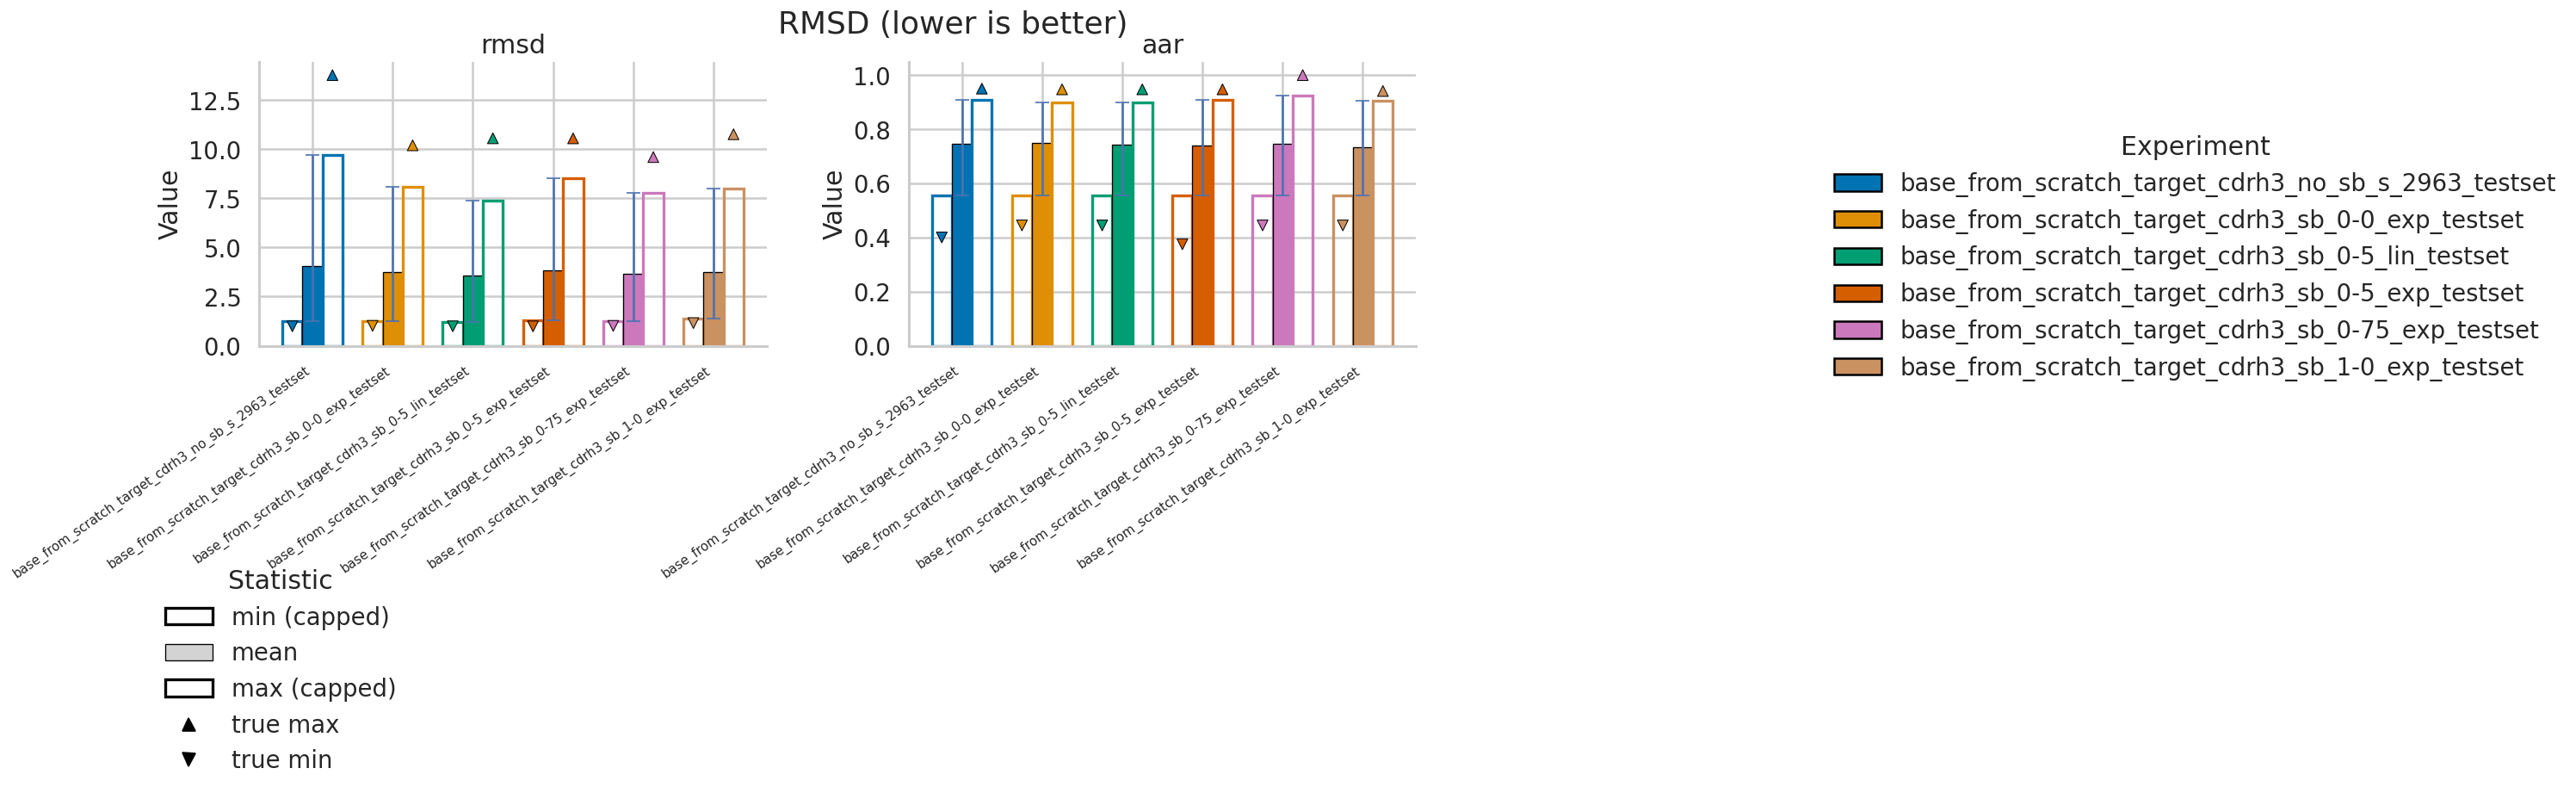

In [14]:
fig = plot_rmsd_summary_bars_seaborn(
    exps,
    cdr_target="H_CDR3",
    title="RMSD (lower is better)",
    value_columns=("rmsd", "aar"),   # or multiple metrics for side-by-side subplots
    confidence_level=0.95,
    cap_percentile=0.95,
    errorbar_percentiles=(5, 95),
    reverse_y=False,
)
# plt.show()  # if not already showing elsewhere


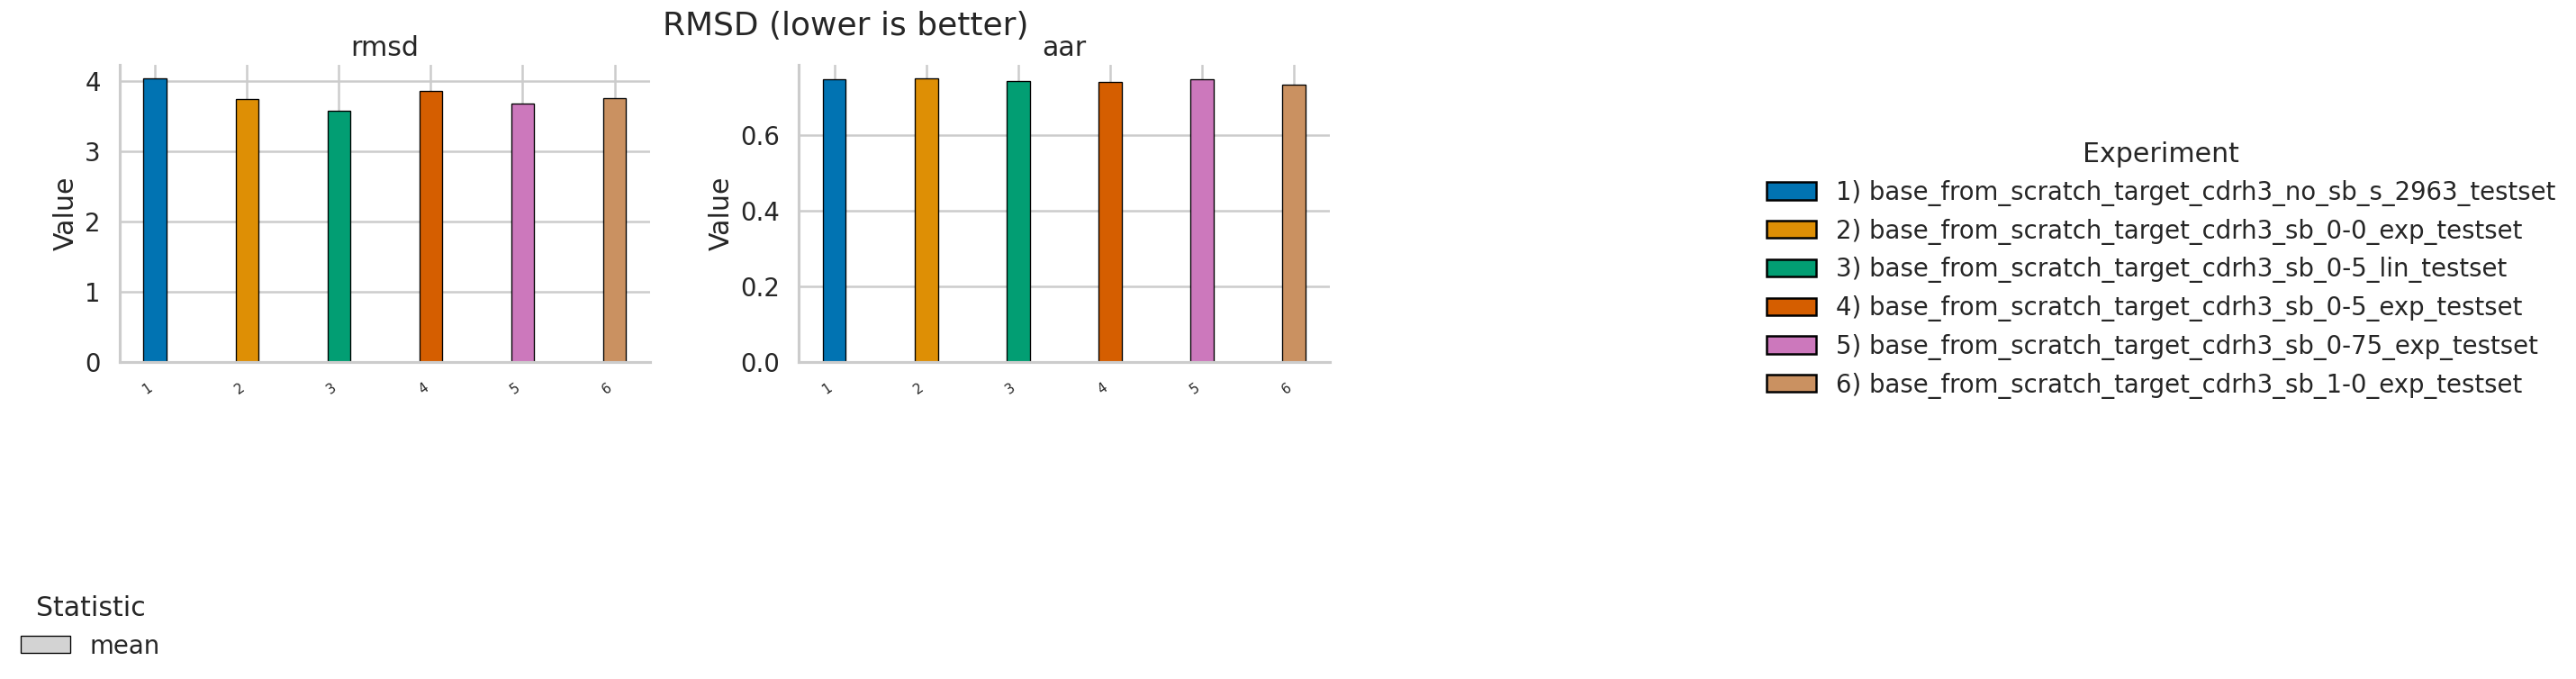

In [15]:
fig = plot_rmsd_summary_bars_seaborn(
    exps,
    cdr_target="H_CDR3",
    title="RMSD (lower is better)",
    value_columns=("rmsd", "aar"),   # or multiple metrics for side-by-side subplots
    confidence_level=0.95,
    cap_percentile=0.95,
    errorbar_percentiles=(5, 95),
    reverse_y=False,
    show_min_max_bars=False,
    show_mean_errorbars=False,
    show_extrema_markers=False,        # if None, falls back to show_outlier_markers
    show_experiment_names=False,
)

In [16]:
# Save to PDF
fig.savefig("summary.pdf", bbox_inches="tight") 